# Planned workflow:
1. Build environment / 搭建环境
2. Check dataset paths and class folders / 检查路径和类别
3. Randomly visualize images / 随机抽图检查
4. Use ImageFolder + transforms / 加载图片并预处理
5. Create DataLoaders / 创建 batch 数据流
6. Build model.py / 写模型结构
7. Build train.py / 写训练流程
8. Train model / 训练模型
9. Plot loss curves and evaluate / 画曲线并评估
10. Save model / 保存模型
11. Predict images from seg_pred / 应用模型预测

In [1]:
from pathlib import Path
import random
import numpy as np
from collections import Counter

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from PIL import Image
import matplotlib.pyplot as plt

from model import SimpleCNN
from train import train

c:\Users\HP\Desktop\DL\PyTorch\CNN\archive\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# define the device to be used for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from importlib import reload
import model, train as train_module

reload(model)
reload(train_module)

SimpleCNN = model.SimpleCNN
train = train_module.train

In [3]:
# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
train size: 14034 Counter({3: 2512, 2: 2404, 5: 2382, 4: 2274, 1: 2271, 0: 2191})
test size: 3000 Counter({2: 553, 3: 525, 4: 510, 5: 501, 1: 474, 0: 437})


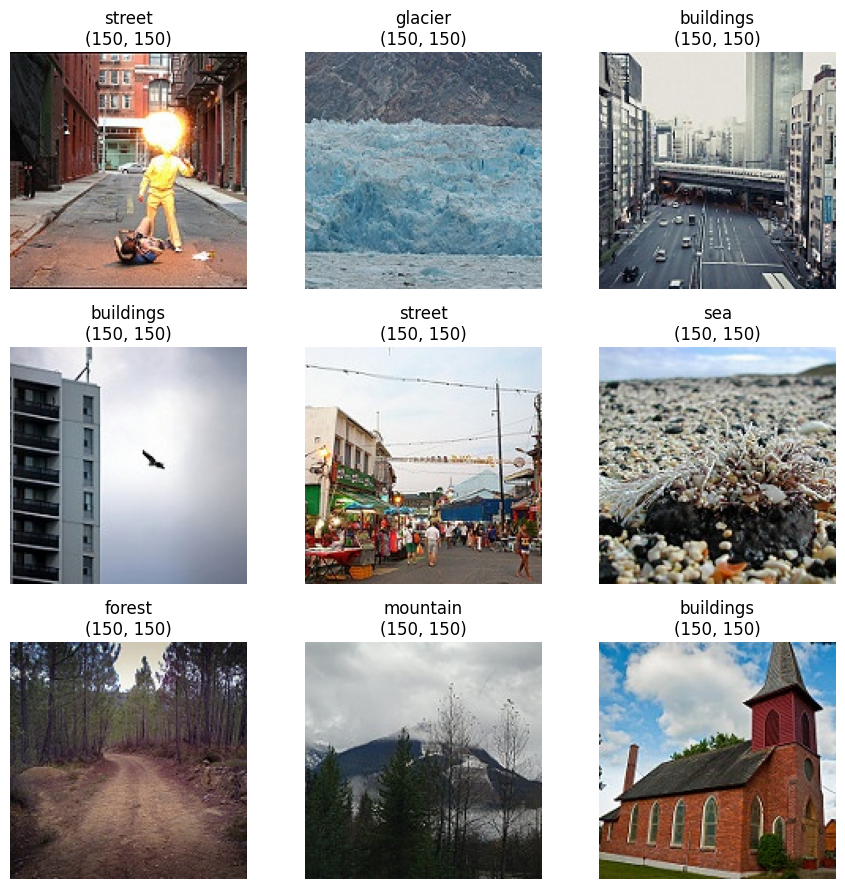

In [4]:
train_dir = Path("seg_train/seg_train")
test_dir = Path("seg_test/seg_test")
pred_dir = Path("seg_pred")

train_data, test_data = datasets.ImageFolder(train_dir), datasets.ImageFolder(test_dir)

print(train_data.classes)
print(train_data.class_to_idx)
print("train size:", len(train_data), Counter(train_data.targets))
print("test size:", len(test_data), Counter(test_data.targets))

plt.figure(figsize=(9, 9))
for i, (p, y) in enumerate(random.sample(train_data.samples, 9)):
    img = Image.open(p).convert("RGB")
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"{train_data.classes[y]}\n{img.size}")
    plt.axis("off")
plt.tight_layout()

torch.Size([64, 3, 150, 150]) torch.Size([64])
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


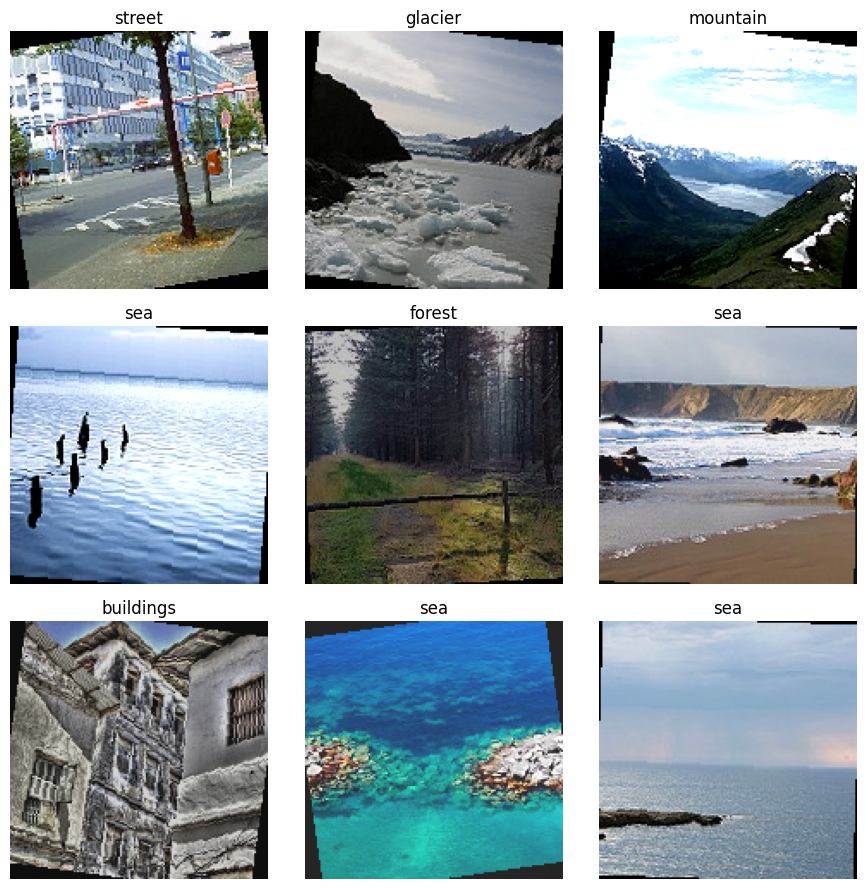

In [5]:
# Data augmentation
train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10), # Adds stronger training augmentation while keeping test images unchanged.
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.ToTensor()
])

transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08)
    ),

transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

# Data preparation
train_data = datasets.ImageFolder(train_dir, transform=train_transform )
test_data = datasets.ImageFolder(test_dir, transform=transform)

# DataLoader
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True,
    num_workers=2,  # num_workers controls how many processes load data in parallel.
    pin_memory=True # Uses parallel data loading for faster GPU training.
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# check the transformed images
x, y = next(iter(train_loader))
print(x.shape, y.shape)
print(train_data.classes)

plt.figure(figsize=(9, 9))
for i, (p, y) in enumerate(random.sample(train_data.samples, 9)):
    img = train_transform(Image.open(p).convert("RGB")).permute(1, 2, 0)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(train_data.classes[y])
    plt.axis("off")
plt.tight_layout()

In [6]:
model = SimpleCNN(num_classes=len(train_data.classes))
out = model(x)

print(out.shape)
print("model device:", next(model.parameters()).device)
print("x device:", x.device)

torch.Size([64, 6])
model device: cpu
x device: cpu


In [ ]:
epochs = 35

print("Using device:", device)

model = SimpleCNN(num_classes=len(train_data.classes)).to(device)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

results = train(model, train_loader, test_loader, loss_fn, optimizer, epochs, device=device)

# Plot loss curves and evaluate
Loss curve<br>Accuracy curve

In [ ]:
plt.figure(figsize=(10, 4))
x = range(1, len(results["train_loss"]) + 1)

plt.subplot(1, 2, 1)
plt.plot(x, results["train_loss"], label="train", linewidth=2)
plt.plot(x, results["test_loss"], label="test", linewidth=2)
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, results["train_acc"], label="train", linewidth=2)
plt.plot(x, results["test_acc"], label="test", linewidth=2)
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()

In [ ]:
import pandas as pd
print({k: round(v[-1], 4) for k, v in results.items()})

In [ ]:
checkpoint = torch.load("models/best.pth", map_location=device)

print("Best epoch:", checkpoint["epoch"])

if "results" in checkpoint:
    results_best = checkpoint["results"]
    print("Best test acc:", round(max(results_best["test_acc"]), 4))
    print("Final train acc in saved history:", round(results_best["train_acc"][-1], 4))
    print("Final test acc in saved history:", round(results_best["test_acc"][-1], 4))

print("Saved keys:", checkpoint.keys())

# Final visualization

In [9]:
# Loads the best saved model for evaluation.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

best_model = SimpleCNN(num_classes=len(test_data.classes)).to(device)

checkpoint = torch.load("models/best.pth", map_location=device)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

C:\Users\HP\AppData\Local\Temp\ipykernel_33660\3422684167.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("models/best.pth", map_location=device)

SimpleCNN(
  (block_1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_3): Sequential(
    (0): Conv2d(32,

In [10]:
# Collects true labels and model predictions from the test set.

y_true = []
y_pred = []

with torch.inference_mode():
    for x, y in test_loader:
        x = x.to(device)
        logits = best_model(x)
        preds = logits.argmax(dim=1).cpu()

        y_true.extend(y.tolist())
        y_pred.extend(preds.tolist())

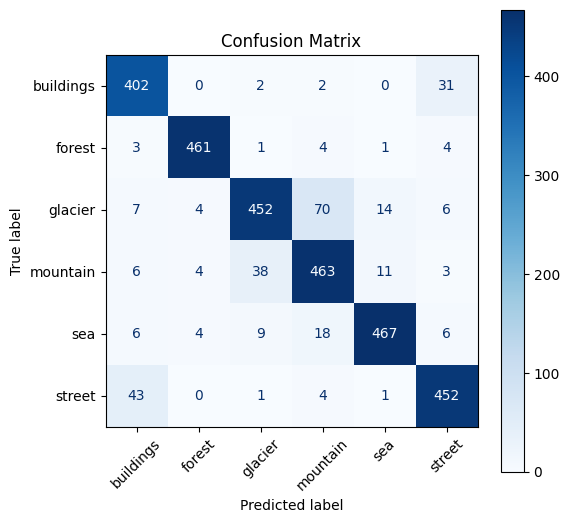

In [12]:
# Visualizes which classes are correctly or incorrectly predicted.

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_data.classes
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Computes accuracy for each class separately.

cm = confusion_matrix(y_true, y_pred)
class_acc = cm.diagonal() / cm.sum(axis=1)

pd.DataFrame({
    "class": test_data.classes,
    "accuracy": class_acc
})

,class,accuracy
0,buildings,0.919908
1,forest,0.972574
2,glacier,0.817360
3,mountain,0.881905
4,sea,0.915686
5,street,0.902196


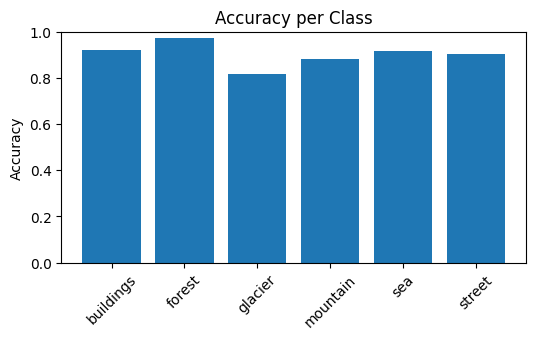

In [20]:
# Shows which classes the model predicts best or worst.
plt.figure(figsize=(6, 3))
plt.bar(test_data.classes, class_acc)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy per Class")
plt.xticks(rotation=45)
plt.show()

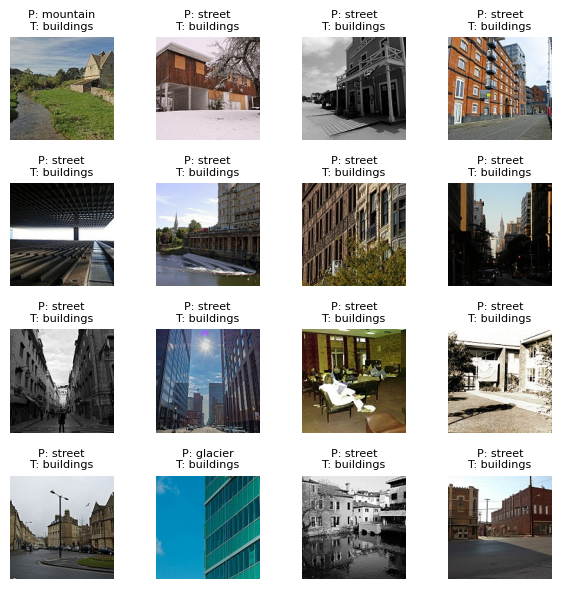

In [23]:
# Stores images where the model prediction is wrong.
wrong_images = []

best_model.eval()

with torch.inference_mode():
    for x, y in test_loader:
        x = x.to(device)
        logits = best_model(x)
        preds = logits.argmax(dim=1).cpu()

        for img, true_label, pred_label in zip(x.cpu(), y, preds):
            if true_label != pred_label:
                wrong_images.append((img, true_label.item(), pred_label.item()))

# Displays examples of wrong predictions.
plt.figure(figsize=(6, 6))

for i, (img, true_label, pred_label) in enumerate(wrong_images[:16]):
    img = img.permute(1, 2, 0)

    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"P: {test_data.classes[pred_label]}\nT: {test_data.classes[true_label]}",
        fontsize=8
    )

plt.tight_layout()
plt.show()                

C:\Users\HP\AppData\Local\Temp\ipykernel_33660\2584316610.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("models/best.pth", map_location=device)

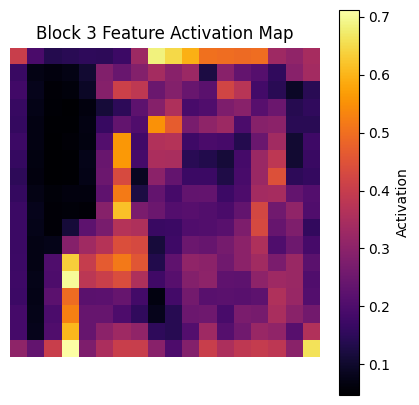

In [27]:
import torch
import matplotlib.pyplot as plt

x, y = next(iter(test_loader))
image = x[0].unsqueeze(0).to(device)

best_model = SimpleCNN(num_classes=len(test_data.classes)).to(device)

checkpoint = torch.load("models/best.pth", map_location=device)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

with torch.inference_mode():
    features = best_model.block_1(image)
    features = best_model.block_2(features)
    features = best_model.block_3(features)

    activation = features.mean(dim=1).squeeze().cpu()

plt.figure(figsize=(5, 5))
plt.imshow(activation, cmap="inferno")
plt.colorbar(label="Activation")
plt.title("Block 3 Feature Activation Map")
plt.axis("off")
plt.show()



C:\Users\HP\AppData\Local\Temp\ipykernel_33660\223490978.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("models/best.pth", map_location=device)


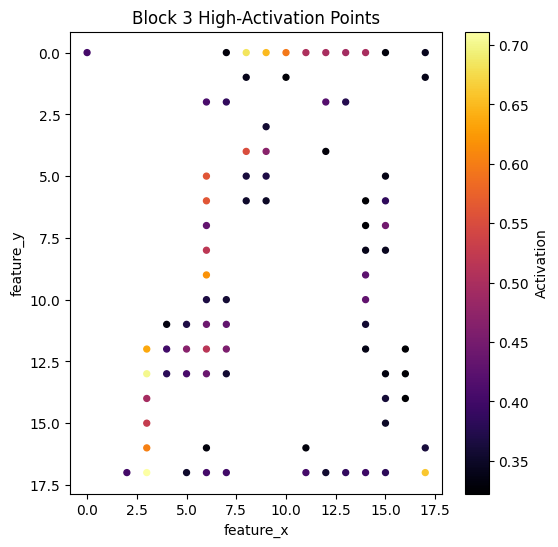

In [28]:
import torch
import matplotlib.pyplot as plt

x, y = next(iter(test_loader))
image = x[0].unsqueeze(0).to(device)

best_model = SimpleCNN(num_classes=len(test_data.classes)).to(device)
checkpoint = torch.load("models/best.pth", map_location=device)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

with torch.inference_mode():
    features = best_model.block_1(image)
    features = best_model.block_2(features)
    features = best_model.block_3(features)
    activation = features.mean(dim=1).squeeze().cpu()

threshold = activation.quantile(0.75)
ys, xs = torch.where(activation > threshold)
values = activation[ys, xs]

plt.figure(figsize=(6, 6))
plt.scatter(xs, ys, c=values, s=18, cmap="inferno")
plt.gca().invert_yaxis()
plt.colorbar(label="Activation")
plt.title("Block 3 High-Activation Points")
plt.xlabel("feature_x")
plt.ylabel("feature_y")
plt.show()